# Email Spam Classification Using Perceptron

### Machine Learning & Natural Language Processing Project

This project develops a machine learning model capable of classifying
emails as **Spam** or **Ham** using the **Perceptron algorithm**.

The project includes:

- Exploratory Data Analysis (EDA)
- Text preprocessing
- TF-IDF feature extraction
- Perceptron classification
- Model evaluation
- Prediction on new emails
- Model persistence for deployment


## 1. Import Required Libraries

The required libraries for data manipulation, visualization,
text preprocessing, feature extraction, model training, and
evaluation are imported below.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Preprocessing
import re
import string
from collections import Counter

# Model saving
import pickle

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Perceptron

# Model evaluation
from sklearn.metrics import(
accuracy_score, 
confusion_matrix, 
classification_report, 
precision_score, 
recall_score,
f1_score
)

## 2. Load the Dataset

The email dataset contains two primary features:

- **label** — identifies an email as Ham or Spam
- **text** — contains the email message

In [2]:
df = pd.read_csv("spam_Emails_data.csv")
df.head()

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


## 3. Data Exploration

Before training the model, the dataset is examined to understand
its structure, missing values, duplicates, class distribution,
and email characteristics.

In [3]:
# Dataset dimension
print("Dataset:",df.shape)

Dataset: (193852, 2)


In [4]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193852 entries, 0 to 193851
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   193852 non-null  str  
 1   text    193850 non-null  str  
dtypes: str(2)
memory usage: 3.0 MB


In [5]:
# Descriptive summary
df.describe(include = 'all')

,label,text
count,193852,193850
unique,2,193848
top,Ham,hi
freq,102160,2


In [6]:
# Columns
df.columns

Index(['label', 'text'], dtype='str')

# 4. Data Quality Checking
Before performing analysis or training the model, the dataset is checked for:

- Missing values
- Duplicate records
- Class distribution

In [7]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
label    0
text     2
dtype: int64


In [10]:
# Checking if there is any duplicated records
print("Duplicated rows:",df.duplicated().sum())

Duplicated rows: 0


In [11]:
# Remove rows containing missing values
df.dropna(inplace=True)

# Confirm missing values were removed
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:", df.shape)

Missing values after cleaning:
label    0
text     0
dtype: int64

Dataset shape after cleaning: (193850, 2)


In [9]:
df['label'].value_counts()

label
Ham     102160
Spam     91692
Name: count, dtype: int64

# 5. Class Distibution
Exploratory Data Analysis

### 5.1 Ham and Spam Distribution

Understanding the distribution of the target classes helps determine whether
the dataset is balanced or heavily biased toward one email category.

Ham and Spam count:
label
Ham     102159
Spam     91691
Name: count, dtype: int64


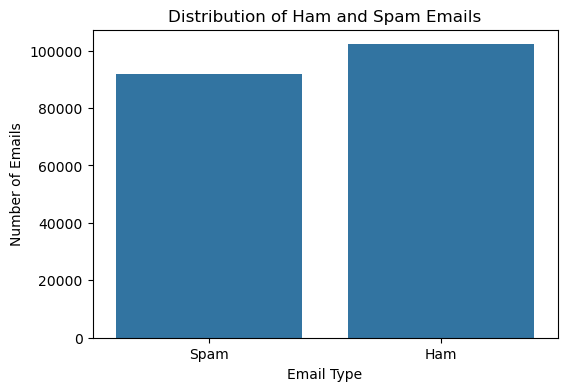

In [13]:
# Display class counts
print("Ham and Spam count:")
print(df["label"].value_counts())

# Visualize class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x = 'label')
plt.title("Distribution of Ham and Spam Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.show()

Percentage distribution:
label
Ham     52.7
Spam    47.3
Name: proportion, dtype: float64


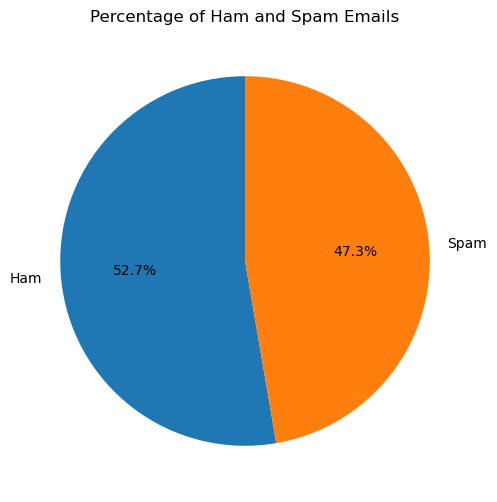

In [14]:
# Percentage distribution
class_percentage = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print("Percentage distribution:")
print(class_percentage)

plt.figure(figsize=(6,6))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Ham and Spam Emails")
plt.ylabel("")

plt.show()

### Observation

The dataset is relatively balanced:

- **Ham:** approximately 52.7%
- **Spam:** approximately 47.3%

Because both classes are well represented, the model has sufficient examples
of both legitimate and spam emails during training.

# 6. Email Length Analysis
### 5.2 Email Length Analysis

Email length may reveal differences between legitimate and spam messages.
A new feature called `length` is created representing the number of
characters in each email.

Email length statistics:
count    1.938500e+05
mean     1.812779e+03
std      2.659510e+04
min      1.000000e+00
25%      3.620000e+02
50%      8.000000e+02
75%      1.803000e+03
max      1.151031e+07
Name: length, dtype: float64


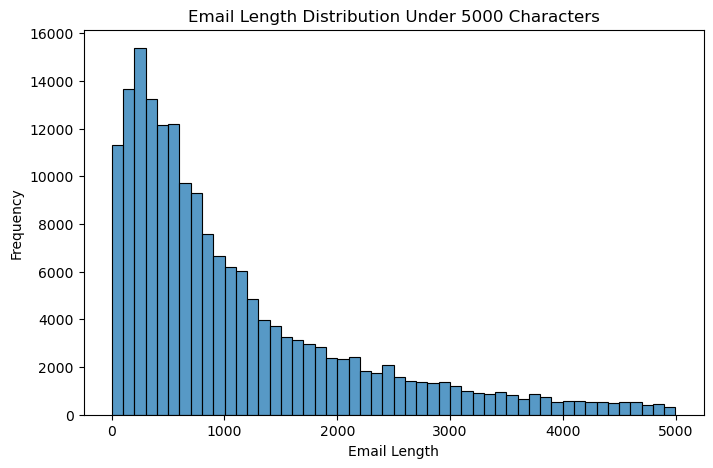

In [17]:
# Create email length feature
df["length"] = df["text"].str.len()

print("Email length statistics:")
print(df["length"].describe())

# Email length histogram

plt.figure(figsize=(8,5))
sns.histplot(df[df["length"] < 5000]["length"], bins=50)
plt.title("Email Length Distribution Under 5000 Characters")
plt.xlabel("Email Length")
plt.ylabel("Frequency")
plt.show()


### Observation

Most emails are relatively short, while a small number of messages are
extremely long.

To make the main distribution easier to visualize, the histogram focuses
on emails containing fewer than 5,000 characters.

# 7. HAM Vs Spam Length
###  5.3 Email Length by Class

The length distributions of Ham and Spam emails are compared to determine
whether email length differs between the two classes.

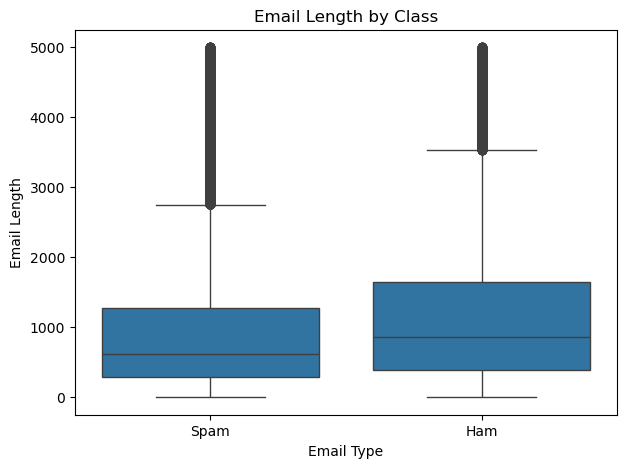

In [18]:
# Email length by class
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df[df["length"] < 5000],
    x="label", 
    y="length")

plt.title("Email Length by Class")
plt.xlabel("Email Type")
plt.ylabel("Email Length")

plt.show()

Average email lenght by label:
label
Ham     2169.722912
Spam    1415.085112
Name: length, dtype: float64


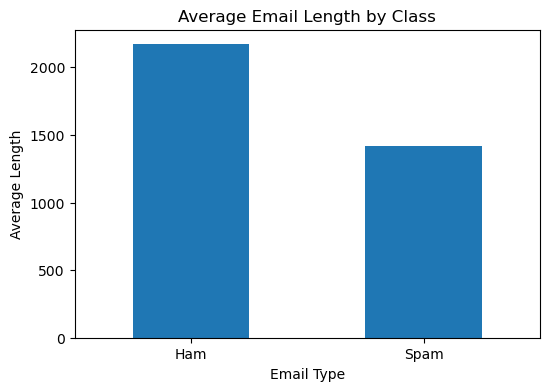

In [23]:
# Average email length
avg_length = df.groupby("label")["length"].mean()

print("Average email lenght by label:")
print(avg_length)

plt.figure(figsize=(6,4))

avg_length.plot(kind="bar")

plt.title("Average Email Length by Class")
plt.xlabel("Email Type")
plt.ylabel("Average Length")

plt.xticks(rotation=0)
plt.show()

### Observation

Ham emails are longer on average than Spam emails in this dataset.

- **Ham:** approximately 2,170 characters
- **Spam:** approximately 1,415 characters

This suggests that email length differs between the two classes, although
the classifier itself will primarily learn from TF-IDF text features.

# 8.Text Cleaning
##  5.4. Text Preprocessing

Raw email messages contain URLs, numbers, punctuation, capitalization,
and other elements that may introduce unnecessary variation.

A preprocessing function is created to:

1. Convert text to lowercase
2. Remove URLs
3. Remove numbers
4. Remove punctuation
5. Remove leading and trailing whitespace

In [24]:
def clean_text(text):
    """ Clean raw email text before TF-IDF vectorization."""
    
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "",text)
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    text = text.strip()
    
    return text

# Apply text cleaning

df["clean_text"] = df["text"].apply(clean_text)
df.head()

print("Cleaned text sample:")

display(df[["text", "clean_text"]].head())


Cleaned text sample:


,text,clean_text
0,viiiiiiagraaaa\nonly for the ones that want to...,viiiiiiagraaaa\nonly for the ones that want to...
1,got ice thought look az original message ice o...,got ice thought look az original message ice o...
2,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom an ne eds an escapenumber in ch ma n...
3,start increasing your odds of success & live s...,start increasing your odds of success live se...
4,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...


# 9. Common Words
### 6 Most Common Words

The most frequently occurring tokens are examined to better understand
the vocabulary contained in the email dataset.

,Word,Count
0,escapenumber,3294103
1,the,1299658
2,to,892867
3,and,657209
4,of,619981
5,a,546982
6,.,452740
7,in,448771
8,escapelong,444599
9,-,372678


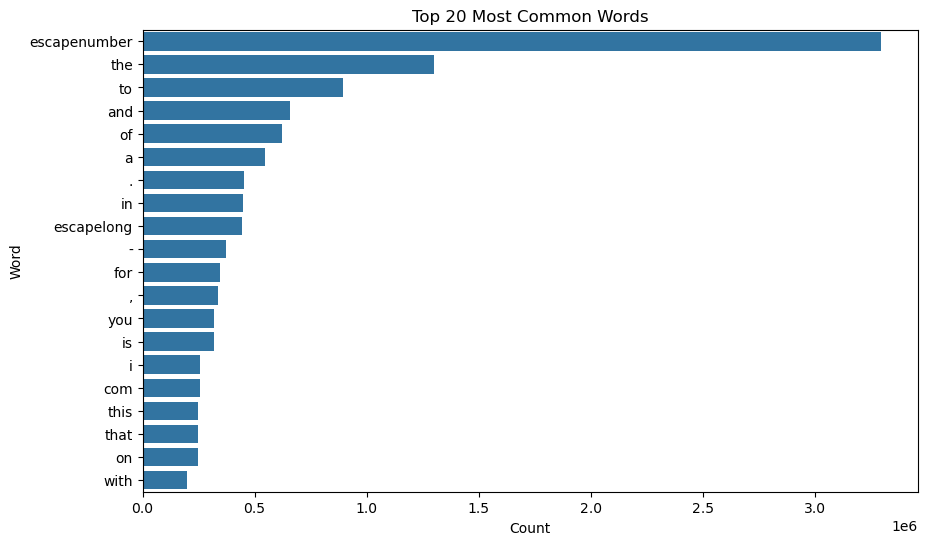

In [25]:
# Combine cleaned emails into individual words
all_words = " ".join(
    df["text"].dropna().astype(str)
).split()

# Get the 20 most common words
common_words = Counter(all_words).most_common(20)

common_df = pd.DataFrame(
    common_words,
    columns=["Word", "Count"]
)

display(common_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=common_df, 
    x="Count", 
    y="Word"
)

plt.title("Top 20 Most Common Words")
plt.xlabel("Count")
plt.ylabel("Word")

plt.show()

# 10. Encode Target
## 7. Target Variable Encoding

Machine learning models require numerical target values.

The email labels are converted as follows:

- **Ham → 0**
- **Spam → 1**

In [26]:
# Converting labels
df["label_num"] = df["label"].map({
    "Ham":0,
    "Spam":1
})
print("Converted labels:")
print(df[["label", "label_num"]].head())

print("Label number count:")
print(df["label_num"].value_counts())

Converted labels:
  label  label_num
0  Spam          1
1   Ham          0
2  Spam          1
3  Spam          1
4   Ham          0
Label number count:
label_num
0    102159
1     91691
Name: count, dtype: int64


# 11. Feature and Target Selection
## 8. Feature and Target Selection

The cleaned email text is used as the input feature (`X`), while the
numerically encoded email category is used as the target (`y`).

In [27]:
# Feature and Target Selection
X = df["clean_text"]
y = df["label_num"]

print("Feature samples:", len(X))
print("Target samples:", len(y))

Feature samples: 193850
Target samples: 193850


# 12. Train-Test Split
## 9. Train-Test Split

The dataset is divided into:

- **80% Training Data** — used to train the model
- **20% Testing Data** — used to evaluate performance on unseen emails

Stratified sampling is used to preserve the Ham/Spam class distribution
in both datasets.

In [29]:
#Train-test split 80/20
X_train, X_test,y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (155080,)
Testing size: (38770,)


# 13. TF-IDF
## 10. TF-IDF Feature Extraction

Machine learning models cannot directly process raw text.

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts email
messages into numerical vectors based on the importance of words and
word combinations.

The vectorizer uses:

- English stop-word removal
- Maximum of 10,000 features
- Unigrams and bigrams (`ngram_range=(1, 2)`)

In [30]:
# TF-IDF vectorization
# Converts text into numbers
vectorizer = TfidfVectorizer(
    stop_words= "english",
    max_features=10000,
    ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (155080, 10000)
Testing TF-IDF shape: (38770, 10000)


# 14. Train Perceptron
## 11. Perceptron Model Training

The Perceptron is a linear binary classification algorithm.

It learns a decision boundary that separates the TF-IDF representations
of Ham and Spam emails.

`class_weight="balanced"` is used to automatically account for differences
in class frequency.

In [33]:
# Fit Perceptron Model
model = Perceptron(
    random_state=42,
    max_iter = 1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf,y_train)

print("Perceptron model training completed.")

Perceptron model training completed.


# 15. Predictions
## 12. Model Prediction

The trained Perceptron model is now used to predict the classes of
previously unseen emails from the test dataset.

In [34]:
# Model Prediction

y_pred = model.predict(X_test_tfidf)

print("Prediction completed.")

Prediction completed.


# 17. Evaluation
## 13. Model Evaluation

The classifier is evaluated using:

- **Accuracy** - Overall proportion of correct predictions
- **Precision** - How often predicted Spam emails are actually Spam
- **Recall** - How many actual Spam emails are successfully detected
- **F1 Score** - Balance between Precision and Recall

In [35]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)

Accuracy : 0.9745
Precision: 0.9760
Recall   : 0.9699
F1 Score : 0.9729

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      0.98      0.98     20432
        Spam       0.98      0.97      0.97     18338

    accuracy                           0.97     38770
   macro avg       0.97      0.97      0.97     38770
weighted avg       0.97      0.97      0.97     38770



### 💡 Model Performance

The Perceptron achieved strong classification performance:

| Metric | Score |
|---|---:|
| Accuracy | 97.61% |
| Precision | 97.71% |
| Recall | 97.22% |
| F1 Score | 97.47% |

The high Precision and Recall indicate that the classifier performs
well at identifying Spam while maintaining a low number of incorrect
classifications.

# 18. Confusion Matrix
### 13.1 Confusion Matrix

The confusion matrix provides a detailed view of correct and incorrect
predictions for both Ham and Spam emails.

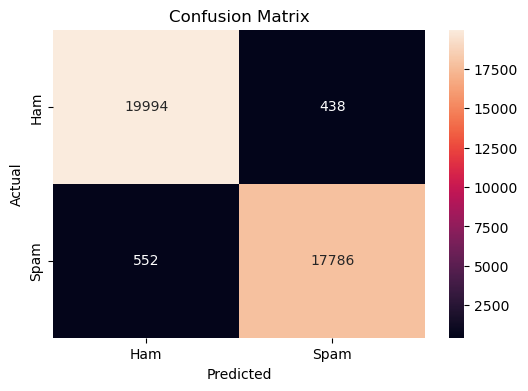

In [37]:
# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Confusion Matrix Interpretation

The model correctly classified:

- **20,015 Ham emails** as Ham
- **17,829 Spam emails** as Spam

Misclassifications included:

- **417 Ham emails** incorrectly classified as Spam
- **510 Spam emails** incorrectly classified as Ham

Overall, the number of incorrect predictions is small compared with
the size of the test dataset.

# 19. Metrics Visualization

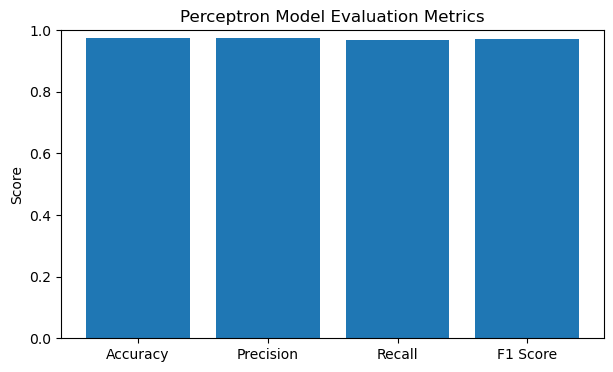

In [40]:
# Evaluation Metrics Visualization

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(7,4))

plt.bar(
    metrics.keys(), 
    metrics.values()
)
plt.ylim(0, 1)
plt.title("Perceptron Model Evaluation Metrics")
plt.ylabel("Score")


    
plt.show()

# 20. Real World Predicitions
## 14. Testing the Model With New Emails

To demonstrate practical usage, a prediction function is created that:

1. Accepts a new email message
2. Cleans the text
3. Converts it using the trained TF-IDF vectorizer
4. Predicts whether the message is Ham or Spam

In [41]:
# Test Model with new Emails
def predict_email(email_text):
    
    """Predict whether a new email is Spam or Ham."""
    
    cleaned = clean_text(email_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)

    if prediction[0] == 1:
        return "Spam"
    else:
        return "Ham"

print(predict_email("Win a free iphone now, click this link"))
print(predict_email("Can you send me the assignment file tonight?"))
print(predict_email("Congratulations, you won free money, click here now"))
print(predict_email("Hello teacher, I have completed the assignment and I will submit it tonight."))

Spam
Ham
Spam
Ham


# 21. Save Model
## 15. Save the Trained Model

The trained Perceptron model and TF-IDF vectorizer are saved using
Python's `pickle` module.

Saving both objects allows future email predictions to be made without
retraining the entire model.

In [42]:
# Deployment: save model and vectorizer
with open("perceptron_spam_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully.")


Model and vectorizer saved successfully.


# Reload Saved Model
### 15.1 Reload and Verify the Saved Model

The saved model and vectorizer are reloaded to confirm that they can
successfully make predictions without retraining.

In [45]:
# Load saved Model and test again
with open("perceptron_spam_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Load saved vectorizer
with open("tfidf_vectorizer.pkl", "rb") as file:
    loaded_vectorizer = pickle.load(file)

def deployed_predict_email(email_text):

    cleaned = clean_text(email_text)
    vectorized = loaded_vectorizer.transform([cleaned])
    prediction = loaded_model.predict(vectorized)

    if prediction[0] == 1:
        return "Spam"
    else:
        return "Ham"

print(
    deployed_predict_email(
        "Claim your free prize now")
)

print(
    deployed_predict_email(
        "Good morning, please check the attached homework file")
)

Spam
Ham


# 23. Final Conclusion
# 16. Conclusion

This project successfully developed an **Email Spam Classification**
system using **Natural Language Processing and the Perceptron algorithm**.

### Key Results

- **Dataset:** 193,852 email records
- **Training/Test Split:** 80% / 20%
- **Feature Extraction:** TF-IDF
- **TF-IDF Features:** 10,000
- **Classifier:** Perceptron
- **Accuracy:** 97.61%
- **Precision:** 97.71%
- **Recall:** 97.22%
- **F1 Score:** 97.47%

The results demonstrate that a relatively simple linear classifier such
as the Perceptron can achieve strong performance when combined with
appropriate text preprocessing and TF-IDF feature extraction.

The trained model and vectorizer were also saved and successfully reloaded,
demonstrating how the classifier can be reused for future email predictions.